Using the past 3.4 index to predict the future 3.4 index
Task A 4.1
1. Data Remain Untouch

Task A 4.2(c)
1. creating testSet file
2. randomly partition the data into another file

Task A 4.2(d)
1. Scaling the Input between 0,1, and denormalised it at the end 
what does the scaling do for the neural network model?


In [1]:
import pandas as pd
import tensorflow as tf
import joblib
import matplotlib.pyplot as plt
import numpy as np

from keras.optimizers import Adam
from keras.models import Sequential
from keras.layers import Dense, Input
from keras.callbacks import EarlyStopping

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# Task 4.1
test_year = pd.read_csv('test_years.csv')
# print(test_year)

data = pd.read_csv('Nino3.4_data.csv')
print("Length of data:", data.shape)
testSet = data[data["year"].isin(test_year["year"])]
# print number of rows (shape is a tuple, can't concatenate directly to a string)
print("Length of testSet:", testSet.shape)

# Task 4.2(c)
remaining = data[~data["year"].isin(test_year["year"])]
print("Length of remaining:", remaining.shape)

# Partition (Split Ratio -> Training and Validation)
trainingSet,validationSet = train_test_split(remaining, test_size=0.33, random_state=69, shuffle=True)

# Task 4.2(d)
# extract the data from the file 
# normalise the data
# save the data to joblib 
scaler = MinMaxScaler()
input = ["nino_tminus2", "nino_tminus1", "nino_t"]
trainingSet[input] = scaler.fit_transform(trainingSet[input])
validationSet[input] = scaler.transform(validationSet[input])

testSet.to_csv('testSet.csv', index=False) # values are unscaled
trainingSet.to_csv('trainingSet.csv', index = False)
validationSet.to_csv('validationSet.csv', index = False)

print("Lenght of trainingSet:", trainingSet.shape)
print("Length of validationSet:", validationSet.shape)
joblib.dump(scaler, 'input_scaler.pkl')


Length of data: (802, 11)
Length of testSet: (72, 11)
Length of remaining: (730, 11)
Lenght of trainingSet: (489, 11)
Length of validationSet: (241, 11)


['input_scaler.pkl']

Model1 -> Output(nino_tplus1)
Task A 4.2(e)
0. setting seed = 69 
1. Traning NN to predict nino_tplus1 using hyperparameters
2. Inputs:  nino_t, nino_tminus1, nino_tminus2
   Target:  nino_tplus1


Epoch 1/1000


/opt/anaconda3/envs/nino/lib/python3.11/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5414 - val_loss: 0.3240
Epoch 2/1000
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1748 - val_loss: 0.1104
Epoch 3/1000
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1025 - val_loss: 0.0939
Epoch 4/1000
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0872 - val_loss: 0.0840
Epoch 5/1000
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0769 - val_loss: 0.0777
Epoch 6/1000
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0707 - val_loss: 0.0739
Epoch 7/1000
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0672 - val_loss: 0.0718
Epoch 8/1000
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0653 - val_loss: 0.0707
Epoch 9/1000
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0644 - val_loss: 0.0701
Epoch 10/1000
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0638 - val_loss: 0.0698
Epoch 11/1000
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0635 - val_loss: 0.0695
Epoch 12/1000
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.06

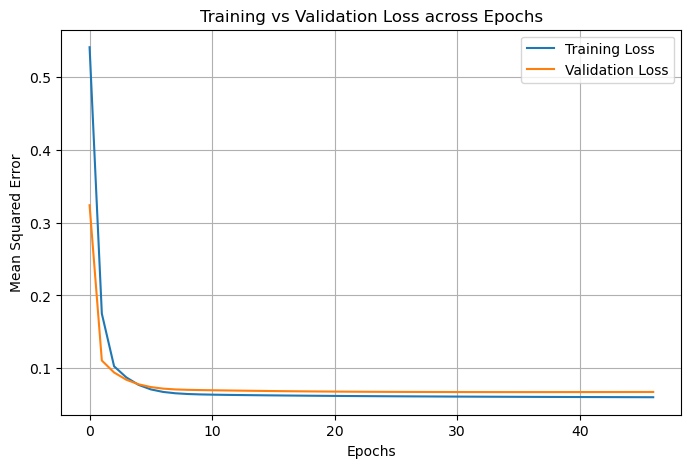

✅ Model trained and saved successfully.


In [2]:
# Task 4.2(e)
np.random.seed(69)
tf.random.set_seed(69)

# Inputs:  nino_t, nino_tminus1, nino_tminus2
# Target:  nino_tplus1
X_train = trainingSet[input]
y_train = trainingSet["nino_tplus1"] #unscaled ans value is be

X_val = validationSet[input]
y_val = validationSet["nino_tplus1"]

model = Sequential([
    Dense(8, activation='tanh', input_shape=(3,)),  # 3 input features
    Dense(1)
])

# Compile the model
model.compile(
    loss='mean_squared_error',
    optimizer=Adam(learning_rate=0.01)
)

es = EarlyStopping(
    monitor="val_loss", mode="min", patience=10, restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=1000,
    batch_size=8,
    callbacks=[es],
    verbose=1
)

# plotting the graph 
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss across Epochs')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.grid(True)
plt.show()

model.save('nino_model1.keras')
print("✅ Model trained and saved successfully.")


# # # 9. Evaluate on test set
# # # -------------------------------
# testSet = pd.read_csv('testSet.csv')
# X_test = testSet[input]
# y_test = testSet["nino_tplus1"].values.reshape(-1,1)

# # Scale inputs
# X_test_scaled = scaler.transform(X_test)

# # Predict and inverse transform
# y_pred_scaled = model.predict(X_test_scaled)
# y_pred = y_pred_scaled

# # Compare predictions
# comparison = pd.DataFrame({
#     "Actual": y_test.flatten(),
#     "Predicted": y_pred.flatten()
# })
# print("First 10 predictions vs actual values:")
# print(comparison.head(10))

# # Plot predictions vs actual
# plt.figure(figsize=(10,5))
# plt.plot(y_test.flatten(), label='Actual', marker='o')
# plt.plot(y_pred.flatten(), label='Predicted', marker='x')
# plt.xlabel('Time Step')
# plt.ylabel('Niño3.4 Index (t+1)')
# plt.title('Predicted vs Actual Niño3.4 Index')
# plt.legend()
# plt.grid(True)
# plt.show()

Task A 4.2
Creating testSet file + randomly partition the data into another file

Model2 -> Output(nino_tplus2)
Inputs:  nino_t, nino_tminus1, nino_tminus2
Target:  nino_tplus2

Epoch 1/1000


/opt/anaconda3/envs/nino/lib/python3.11/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5654 - val_loss: 0.3362
Epoch 2/1000
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1734 - val_loss: 0.2320
Epoch 3/1000
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1086 - val_loss: 0.2142
Epoch 4/1000
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0896 - val_loss: 0.2023
Epoch 5/1000
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0779 - val_loss: 0.1948
Epoch 6/1000
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0718 - val_loss: 0.1901
Epoch 7/1000
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0688 - val_loss: 0.1873
Epoch 8/1000
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0672 - val_loss: 0.1859
Epoch 9/1000
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0664 - val_loss: 0.1849
Epoch 10/1000
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0658 - val_loss: 0.1842
Epoch 11/1000
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0654 - val_loss: 0.1834
Epoch 12/1000
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.06

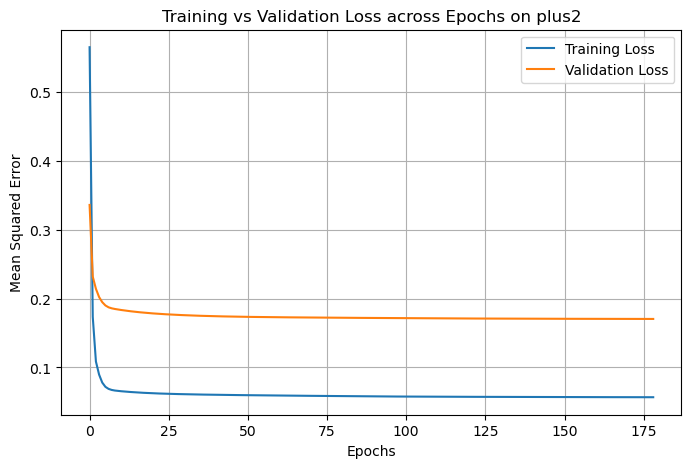

✅ Model trained and saved successfully.


In [3]:
X_train = trainingSet[input]
y_trian = trainingSet["nino_tplus2"]

X_val = validationSet[input]
y_val = validationSet["nino_tplus2"]

model = Sequential([
    Dense(8, activation='tanh', input_shape=(3,)),  # 3 input features
    Dense(1)
])

model.compile(
    loss='mean_squared_error',
     optimizer=Adam(learning_rate=0.01)
)

es = EarlyStopping(
    monitor="val_loss", mode="min", patience=10, restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=1000,
    batch_size=8,
    callbacks=[es],
    verbose=1
)

# plotting the graph 
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss across Epochs on plus2')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.grid(True)
plt.show()

model.save('nino_model2.keras')
print("✅ Model trained and saved successfully.")


Model3 -> Output(nino_tplus3)
Task A 4.2(e)
0. setting seed = 69 
1. Traning NN to predict nino_tplus1 using hyperparameters
2. Inputs:  nino_t, nino_tminus1, nino_tminus2
   Target:  nino_tplus3


Epoch 1/1000


/opt/anaconda3/envs/nino/lib/python3.11/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5088 - val_loss: 0.3754
Epoch 2/1000
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1787 - val_loss: 0.3517
Epoch 3/1000
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1228 - val_loss: 0.3425
Epoch 4/1000
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1050 - val_loss: 0.3297
Epoch 5/1000
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0915 - val_loss: 0.3195
Epoch 6/1000
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0816 - val_loss: 0.3114
Epoch 7/1000
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0747 - val_loss: 0.3050
Epoch 8/1000
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0703 - val_loss: 0.3002
Epoch 9/1000
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0676 - val_loss: 0.2970
Epoch 10/1000
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0661 - val_loss: 0.2949
Epoch 11/1000
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0653 - val_loss: 0.2935
Epoch 12/1000
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.06

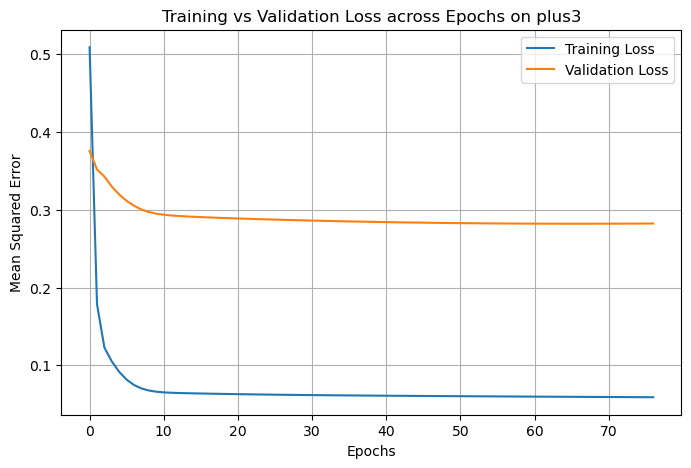

✅ Model trained and saved successfully.


In [4]:
X_train = trainingSet[input]
y_trian = trainingSet["nino_tplus3"]

X_val = validationSet[input]
y_val = validationSet["nino_tplus3"]

model = Sequential([
    Dense(8, activation='tanh', input_shape=(3,)),  # 3 input features
    Dense(1)
])

model.compile(
    loss='mean_squared_error',
     optimizer=Adam(learning_rate=0.01)
)

es = EarlyStopping(
    monitor="val_loss", mode="min", patience=10, restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=1000,
    batch_size=8,
    callbacks=[es],
    verbose=1
)

# plotting the graph 
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss across Epochs on plus3')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.grid(True)
plt.show()

model.save('nino_model3.keras')
print("✅ Model trained and saved successfully.")


Model4 -> Output(nino_tplus4)
Task A 4.2(e)
0. setting seed = 69 
1. Traning NN to predict nino_tplus1 using hyperparameters
2. Inputs:  nino_t, nino_tminus1, nino_tminus2
   Target:  nino_tplus4

Epoch 1/1000


/opt/anaconda3/envs/nino/lib/python3.11/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7789 - val_loss: 0.6072
Epoch 2/1000
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4696 - val_loss: 0.4458
Epoch 3/1000
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2488 - val_loss: 0.4053
Epoch 4/1000
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1422 - val_loss: 0.4407
Epoch 5/1000
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1137 - val_loss: 0.4524
Epoch 6/1000
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1020 - val_loss: 0.4478
Epoch 7/1000
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0931 - val_loss: 0.4407
Epoch 8/1000
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0858 - val_loss: 0.4339
Epoch 9/1000
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0798 - val_loss: 0.4278
Epoch 10/1000
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0750 - val_loss: 0.4226
Epoch 11/1000
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0712 - val_loss: 0.4182
Epoch 12/1000
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.06

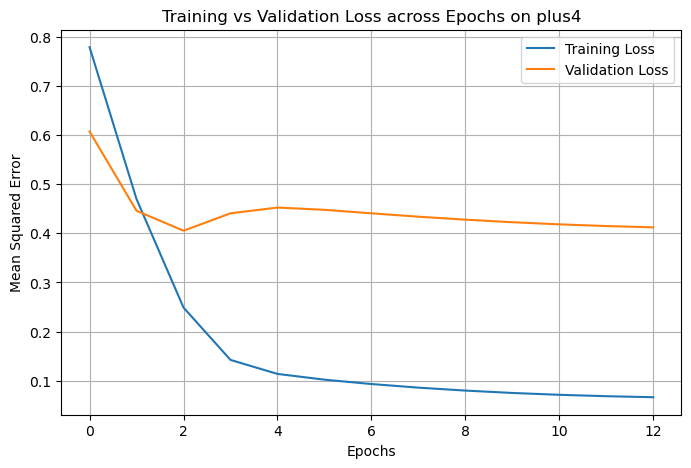

✅ Model4 trained and saved successfully.


In [ ]:
X_train = trainingSet[input]
y_trian = trainingSet["nino_tplus4"]

X_val = validationSet[input]
y_val = validationSet["nino_tplus4"]

model4 = Sequential([
    Dense(8, activation='tanh', input_shape=(3,)),  # 3 input features
    Dense(8, activation='tanh'),
    Dense(1)
])

model4.compile(
    loss='mean_squared_error',
     optimizer=Adam(learning_rate=0.005)
)

es = EarlyStopping(
    monitor="val_loss", mode="min", patience=10, restore_best_weights=True
)

history = model4.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=1000,
    batch_size=8,
    callbacks=[es],
    verbose=1
)

# plotting the graph 
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss across Epochs on plus4')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.grid(True)
plt.show()

model4.save('nino_model4.keras')
print("✅ Model4 trained and saved successfully.")


Model5 -> Output(nino_tplus4)
Task A 4.2(e)
0. setting seed = 69 
1. Traning NN to predict nino_tplus1 using hyperparameters
2. Inputs:  nino_t, nino_tminus1, nino_tminus2
   Target:  nino_tplus5

Epoch 1/1000


/opt/anaconda3/envs/nino/lib/python3.11/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.7305 - val_loss: 0.5192
Epoch 2/1000
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.6286 - val_loss: 0.5010
Epoch 3/1000
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.5942 - val_loss: 0.4969
Epoch 4/1000
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.5794 - val_loss: 0.4846
Epoch 5/1000
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.5691 - val_loss: 0.4750
Epoch 6/1000
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.5612 - val_loss: 0.4677
Epoch 7/1000
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.5551 - val_loss: 0.4616
Epoch 8/1000
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.5502 - val_loss: 0.4562
Epoch 9/1000
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.5462 - val_loss: 0.4512
Epoch 10/1000
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.5428 - val_loss: 0.4465
Epoch 11/1000
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.5398 - val_loss: 0.4421
Epoch 12/1000
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.53

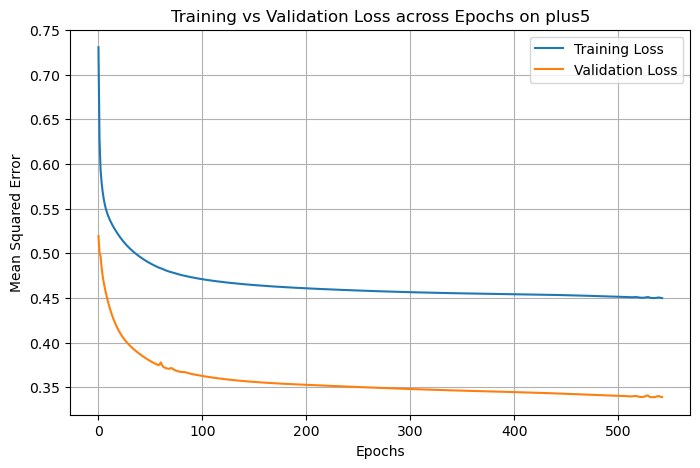

✅ Model5 trained and saved successfully.


In [7]:
X_train = trainingSet[input]
y_train = trainingSet['nino_tplus5']

X_val = validationSet[input]
y_val = validationSet['nino_tplus5']

model5 = Sequential([
    Dense(8, activation='tanh', input_shape=(3,)),  # 3 input features
    Dense(1)
])

model5.compile(
    loss='mean_squared_error',
     optimizer=Adam(learning_rate=0.01)
)

es = EarlyStopping(
    monitor="val_loss", mode="min", patience=10, restore_best_weights=True
)

history = model5.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=1000,
    batch_size=8,
    callbacks=[es],
    verbose=1
)

# plotting the graph 
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss across Epochs on plus5')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.grid(True)
plt.show()

model5.save('nino_model5.keras')
print("✅ Model5 trained and saved successfully.")

Model5 -> Output(nino_tplus4)
Task A 4.2(e)
0. setting seed = 69 
1. Traning NN to predict nino_tplus1 using hyperparameters
2. Inputs:  nino_t, nino_tminus1, nino_tminus2
   Target:  nino_tplus6

Epoch 1/1000


/opt/anaconda3/envs/nino/lib/python3.11/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.8637 - val_loss: 0.6354
Epoch 2/1000
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.7895 - val_loss: 0.5982
Epoch 3/1000
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.7463 - val_loss: 0.5730
Epoch 4/1000
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.7112 - val_loss: 0.5522
Epoch 5/1000
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.6814 - val_loss: 0.5358
Epoch 6/1000
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.6574 - val_loss: 0.5237
Epoch 7/1000
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.6386 - val_loss: 0.5149
Epoch 8/1000
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.6243 - val_loss: 0.5082
Epoch 9/1000
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.6133 - val_loss: 0.5026
Epoch 10/1000
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.6050 - val_loss: 0.4977
Epoch 11/1000
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.5986 - val_loss: 0.4933
Epoch 12/1000
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.59

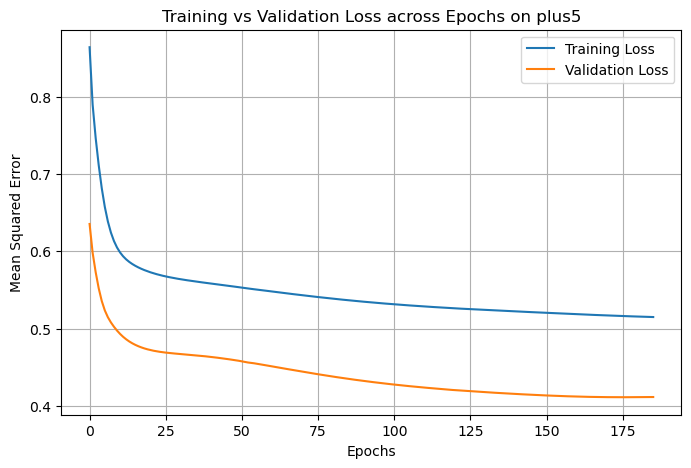

✅ Model6 trained and saved successfully.


In [8]:
X_train = trainingSet[input]
y_train = trainingSet['nino_tplus6']

X_val = validationSet[input]
y_val = validationSet['nino_tplus6']

model6 = Sequential([
    Dense(8, activation='tanh', input_shape=(3,)),  # 3 input features
    Dense(1)
])

model6.compile(
    loss='mean_squared_error',
     optimizer=Adam(learning_rate=0.01)
)

es = EarlyStopping(
    monitor="val_loss", mode="min", patience=10, restore_best_weights=True
)

history = model6.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=1000,
    batch_size=8,
    callbacks=[es],
    verbose=1
)

# plotting the graph 
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss across Epochs on plus5')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.grid(True)
plt.show()

model6.save('nino_model6.keras')
print("✅ Model6 trained and saved successfully.")

4.3(j)
apply same transformation on the testSet

4.3(k)
use the testData input to model to forcast the 1-6 months indexs

4.3(i)
evalutate the RMSE and Pearson Correlation Coeff between predicted and true vlaue




In [9]:
testData = pd.read_csv('testSet.csv')

#4.3(j)
X_test = testData[input]
scaler = joblib.load('input_scaler.pkl')
X_trans = scaler.transform(X_test)

#4.3(k)
model1 = tf.keras.models.load_model('nino_model1.keras')
model2 = tf.keras.models.load_model('nino_model2.keras')
model3 = tf.keras.models.load_model('nino_model3.keras')
model4 = tf.keras.models.load_model('nino_model4.keras')
model5 = tf.keras.models.load_model('nino_model5.keras')
model6 = tf.keras.models.load_model('nino_model6.keras')

prediction1 = model1.predict(X_trans)
prediction2 = model2.predict(X_trans)
prediction3 = model3.predict(X_trans)
prediction4 = model4.predict(X_trans)
prediction5 = model5.predict(X_trans)
prediction6 = model6.predict(X_trans)

#4.3(i)
model1_actual = testData['nino_tplus1'].values
model2_actual = testData['nino_tplus2'].values
model3_actual = testData['nino_tplus3'].values
model4_actual = testData['nino_tplus4'].values
model5_actual = testData['nino_tplus5'].values
model6_actual = testData['nino_tplus6'].values


rmse1 = np.sqrt(np.mean((prediction1.flatten() - model1_actual) ** 2))
rmse2 = np.sqrt(np.mean((prediction2.flatten() - model2_actual) ** 2))
rmse3 = np.sqrt(np.mean((prediction3.flatten() - model3_actual) ** 2))
rmse4 = np.sqrt(np.mean((prediction4.flatten() - model4_actual) ** 2))
rmse5 = np.sqrt(np.mean((prediction5.flatten() - model5_actual) ** 2))
rmse6 = np.sqrt(np.mean((prediction6.flatten() - model6_actual) ** 2))

# Correlation
co1 = np.corrcoef(prediction1.flatten(), model1_actual)[0, 1]
co2 = np.corrcoef(prediction2.flatten(), model2_actual)[0, 1]
co3 = np.corrcoef(prediction3.flatten(), model3_actual)[0, 1]
co4 = np.corrcoef(prediction4.flatten(), model4_actual)[0, 1]
co5 = np.corrcoef(prediction5.flatten(), model5_actual)[0, 1]
co6 = np.corrcoef(prediction6.flatten(), model6_actual)[0, 1]

rmse_list = [rmse1, rmse2, rmse3, rmse4, rmse5, rmse6]
pearson_list = [co1, co2, co3, co4, co5, co6]

results_df = pd.DataFrame({
    "RMSE": rmse_list,
    "Pearson_corr": pearson_list
}, index=[f"t+{i}" for i in range(1, 7)])

print(results_df)
results_df.to_csv("TaskA_Evaluation.csv")
print("✅ CSV file saved as 'TaskA_Evaluation.csv'")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/stepWARNING:tensorflow:6 out of the last 9 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x3029272e0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
         RMSE  P

4.4(n)
learning transfer
train with t+1 and train with t+2 ---> t+6, using the weight from the previous model to train the current model

In [10]:
# retrain model1 with scaled[input] target[nino_tplus1]
# train model2 with scaled[input] target[nino_tplus2]
#...
# train model6 with scaled[input] target[nino_tplus6]
# Load model trained on t+1
base_model = tf.keras.models.load_model("nino_model1.keras")

# Unfreeze all layers for full fine-tuning
base_model.trainable = True
base_model.compile(loss='mean_squared_error', optimizer=Adam(learning_rate=1e-4))

es = EarlyStopping(monitor="val_loss", mode="min", patience=10, restore_best_weights=True)

# Load data
trainingSet = pd.read_csv("trainingSet.csv")
validationSet = pd.read_csv("validationSet.csv")
testSet = pd.read_csv("testSet.csv")

# Scale inputs
X_train = trainingSet[input]
X_val = validationSet[input]
X_test = scaler.transform(testSet[input])

rmse_list = []
pearson_list = []
forecast_horizons = []

for i in range(2, 7):
    print(f"\n🔁 Fine-tuning for nino_tplus{i}")

    y_train = trainingSet[f"nino_tplus{i}"].values.reshape(-1, 1)
    y_val = validationSet[f"nino_tplus{i}"].values.reshape(-1, 1)
    y_test = testSet[f"nino_tplus{i}"].values.reshape(-1, 1)

    # Scale outputs (helps stabilize learning)
    out_scaler = MinMaxScaler()
    y_train_scaled = out_scaler.fit_transform(y_train)
    y_val_scaled = out_scaler.transform(y_val)

    # Fine-tune
    base_model.fit(
        X_train, y_train_scaled,
        validation_data=(X_val, y_val_scaled),
        epochs=100,
        batch_size=8,
        callbacks=[es],
        verbose=0
    )

    # Predict & inverse scale
    y_pred_scaled = base_model.predict(X_test)
    y_pred = out_scaler.inverse_transform(y_pred_scaled)

    # Evaluate
    rmse = np.sqrt(np.mean((y_pred.flatten() - y_test.flatten()) ** 2))
    corr = np.corrcoef(y_pred.flatten(), y_test.flatten())[0, 1]

    rmse_list.append(rmse)
    pearson_list.append(corr)
    forecast_horizons.append(f"t+{i}")

    print(f"✅ t+{i}: RMSE={rmse:.4f}, Pearson={corr:.4f}")

    # Save model for this horizon
    base_model.save(f"Transfered_model_tplus{i}.keras")

# Save results
results_df = pd.DataFrame({
    "Horizon": forecast_horizons,
    "RMSE": rmse_list,
    "Pearson_corr": pearson_list
})
results_df.to_csv("transfer_learning_results_fixed.csv", index=False)
print("\n📄 Saved 'transfer_learning_results_fixed.csv'")
print(results_df)


🔁 Fine-tuning for nino_tplus2
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
✅ t+2: RMSE=0.6169, Pearson=0.9115

🔁 Fine-tuning for nino_tplus3
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
✅ t+3: RMSE=0.5742, Pearson=0.8205

🔁 Fine-tuning for nino_tplus4
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
✅ t+4: RMSE=0.6452, Pearson=0.7522

🔁 Fine-tuning for nino_tplus5
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
✅ t+5: RMSE=0.7127, Pearson=0.6822

🔁 Fine-tuning for nino_tplus6
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
✅ t+6: RMSE=0.7732, Pearson=0.6086

📄 Saved 'transfer_learning_results_fixed.csv'
  Horizon      RMSE  Pearson_corr
0     t+2  0.616926      0.911498
1     t+3  0.574232      0.820518
2     t+4  0.645183      0.752168
3     t+5  0.712697      0.682215
4     t+6  0.773218      0.608570
